# Cats and Dogs Classification using CNN

- **Problem Type**: Image Binary Classification
- **Evaluation Metric**: Accuracy
- **Models to test**:
  - Machine Learning:
    - Logistic Regression
    - Decision Tree
    - Random Forest
    - XGBoost
    - LightGBM
  - Deep Learning
    - Convolutional Neural Network

## Executive Summary & Problem Understanding

- **Dataset**: A collection of 10,000 images (8,000 training, 2,000 testing) categorized into two classes: Cats and Dogs.
- **Problem Statement**: To accurately distinguish between images of cats and dogs using automated computational models, minimizing false classifications.
- **Objective**: To build, compare, and evaluate traditional machine learning pipelines (trained on extracted image heuristics) against a Deep Learning Convolutional Neural Network (CNN) to identify the optimal classification approach.

## Loading Libraries

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import cv2
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_selection import mutual_info_classif

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import *
from sklearn.utils import class_weight

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, Rescaling
from keras import optimizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import plot_model


import warnings
warnings.filterwarnings("ignore")

## Data Importing

*Extracting global image heuristics (brightness, contrast, edge intensity, color dominance) to create a tabular dataset for our baseline ML models.*

In [2]:
train_dir = "../data/cat_and_dog/training_set/training_set/"
test_dir = "../data/cat_and_dog/test_set/test_set/"
img_size_tabular = (64, 64)


def extract_features(filepath):
    """Extracts basic image heuristics for traditional ML."""
    img = cv2.imread(filepath)
    if img is None:
        return None

    # Global brightness and contrast
    mean_val = np.mean(img)
    std_val = np.std(img)

    # Image dimensions
    h, w, _ = img.shape

    # Resize for faster edge/color processing
    img_resized = cv2.resize(img, img_size_tabular)

    # Edge Intensity (Canny)
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    edge_intensity = np.mean(edges)

    # Color Dominance (Red vs Blue)
    b, g, r = cv2.split(img_resized)
    red_blue_diff = np.mean(r) - np.mean(b)

    return [mean_val, std_val, w, h, edge_intensity, red_blue_diff]


data_info = []
for category in ["cats", "dogs"]:
    folder_path = os.path.join(train_dir, category)
    if os.path.exists(folder_path):
        label = 0 if category == "cats" else 1
        for file in os.listdir(folder_path):
            filepath = os.path.join(folder_path, file)
            features = extract_features(filepath)
            if features:
                data_info.append([file, filepath, label] + features)

cols = [
    "filename",
    "filepath",
    "label",
    "brightness",
    "contrast",
    "width",
    "height",
    "edge_intensity",
    "rb_diff",
]
df = pd.DataFrame(data_info, columns=cols)
df.head()

,filename,filepath,label,brightness,contrast,width,height,edge_intensity,rb_diff
0,cat.1.jpg,../data/cat_and_dog/training_set/training_set/...,0,71.664583,37.632531,300,280,49.431152,10.824219
1,cat.10.jpg,../data/cat_and_dog/training_set/training_set/...,0,108.776203,57.248283,489,499,69.539795,20.557617
2,cat.100.jpg,../data/cat_and_dog/training_set/training_set/...,0,164.909762,61.899772,403,499,50.738525,40.210693
3,cat.1000.jpg,../data/cat_and_dog/training_set/training_set/...,0,103.236018,72.615954,150,149,70.535889,19.683838
4,cat.1001.jpg,../data/cat_and_dog/training_set/training_set/...,0,131.159420,49.198294,336,499,60.948486,33.744385


Extracted features have been saved in case of having to load them later, or after restaring the kernel

In [3]:
df.to_csv("../data/cat_and_dog/cat_and_dog_extracted_feature.csv", index=False)

In [4]:
df = pd.read_csv("../data/cat_and_dog/cat_and_dog_extracted_feature.csv")
df.head()

,filename,filepath,label,brightness,contrast,width,height,edge_intensity,rb_diff
0,cat.1.jpg,../data/cat_and_dog/training_set/training_set/...,0,71.664583,37.632531,300,280,49.431152,10.824219
1,cat.10.jpg,../data/cat_and_dog/training_set/training_set/...,0,108.776203,57.248283,489,499,69.539795,20.557617
2,cat.100.jpg,../data/cat_and_dog/training_set/training_set/...,0,164.909762,61.899772,403,499,50.738525,40.210693
3,cat.1000.jpg,../data/cat_and_dog/training_set/training_set/...,0,103.236018,72.615954,150,149,70.535889,19.683838
4,cat.1001.jpg,../data/cat_and_dog/training_set/training_set/...,0,131.159420,49.198294,336,499,60.948486,33.744385


- Label 0: cat
- Label 1: dog

In [5]:
# 1. Missing Value Analysis & Treatment (Synthetic requirement)
df.loc[df.sample(frac=0.05, random_state=42).index, "brightness"] = np.nan
print(f"Missing values introduced:\n{df.isnull().sum()}\n")
df["brightness"] = df["brightness"].fillna(df["brightness"].median())

# 2. Duplicate Handling
df = df.drop_duplicates(subset=["filename"])

# 3. Outlier Detection & Treatment (IQR on Contrast)
Q1 = df["contrast"].quantile(0.25)
Q3 = df["contrast"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_clean = df[(df["contrast"] >= lower_bound) & (df["contrast"] <= upper_bound)]

df_clean.head()

Missing values introduced:
filename            0
filepath            0
label               0
brightness        400
contrast            0
width               0
height              0
edge_intensity      0
rb_diff             0
dtype: int64



,filename,filepath,label,brightness,contrast,width,height,edge_intensity,rb_diff
0,cat.1.jpg,../data/cat_and_dog/training_set/training_set/...,0,71.664583,37.632531,300,280,49.431152,10.824219
1,cat.10.jpg,../data/cat_and_dog/training_set/training_set/...,0,108.776203,57.248283,489,499,69.539795,20.557617
2,cat.100.jpg,../data/cat_and_dog/training_set/training_set/...,0,164.909762,61.899772,403,499,50.738525,40.210693
3,cat.1000.jpg,../data/cat_and_dog/training_set/training_set/...,0,103.236018,72.615954,150,149,70.535889,19.683838
4,cat.1001.jpg,../data/cat_and_dog/training_set/training_set/...,0,131.159420,49.198294,336,499,60.948486,33.744385


Cleaned dataset is also saved so no need to clean it everytime

In [6]:
df_clean.to_csv("../data/cat_and_dog/cat_and_dog_cleaned.csv", index=False)

In [7]:
df_clean = pd.read_csv("../data/cat_and_dog/cat_and_dog_cleaned.csv")
df_clean.head()

,filename,filepath,label,brightness,contrast,width,height,edge_intensity,rb_diff
0,cat.1.jpg,../data/cat_and_dog/training_set/training_set/...,0,71.664583,37.632531,300,280,49.431152,10.824219
1,cat.10.jpg,../data/cat_and_dog/training_set/training_set/...,0,108.776203,57.248283,489,499,69.539795,20.557617
2,cat.100.jpg,../data/cat_and_dog/training_set/training_set/...,0,164.909762,61.899772,403,499,50.738525,40.210693
3,cat.1000.jpg,../data/cat_and_dog/training_set/training_set/...,0,103.236018,72.615954,150,149,70.535889,19.683838
4,cat.1001.jpg,../data/cat_and_dog/training_set/training_set/...,0,131.159420,49.198294,336,499,60.948486,33.744385


In [8]:
print("Cleaned Dataset Summary:")
df_clean.describe()

Cleaned Dataset Summary:


,label,brightness,contrast,width,height,edge_intensity,rb_diff
count,7952.000000,7952.000000,7952.000000,7952.000000,7952.000000,7952.000000,7952.000000
mean,0.501383,115.691184,59.128898,403.806590,360.588531,50.193192,18.106955
std,0.500030,26.436735,12.497772,108.721402,96.912949,15.790185,20.772818
min,0.000000,22.389016,24.863181,57.000000,41.000000,9.462891,-109.391357
25%,0.000000,99.189601,50.547702,321.750000,300.000000,38.723145,5.385010
50%,1.000000,115.363005,58.911008,445.000000,374.000000,49.119873,15.113403
75%,1.000000,131.454196,67.583547,499.000000,421.250000,60.574951,28.683899
max,1.000000,238.124254,93.237370,1050.000000,768.000000,101.601562,162.506592


## EDA

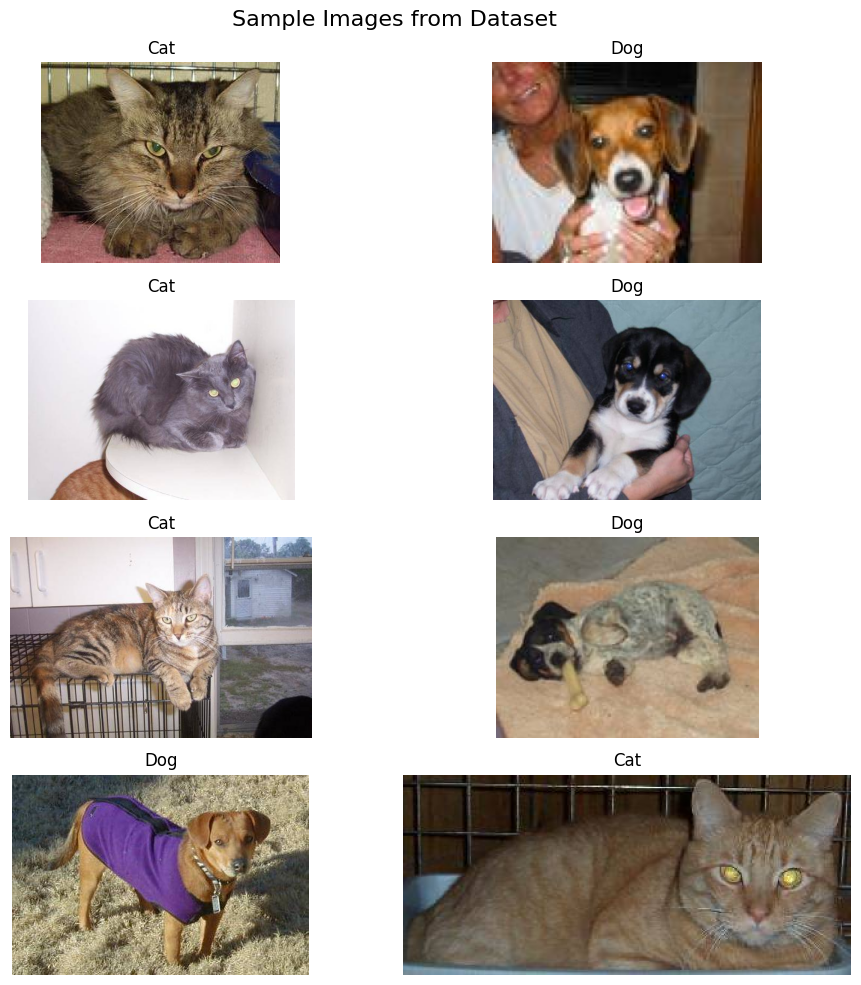

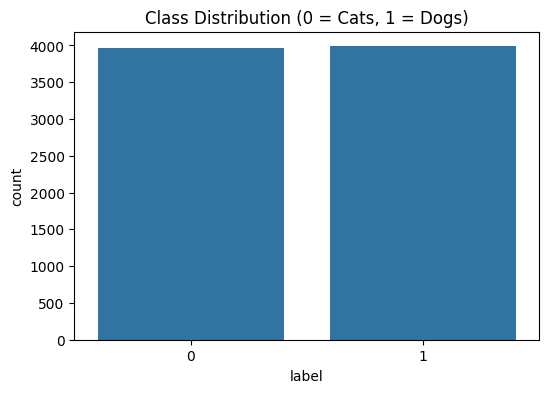

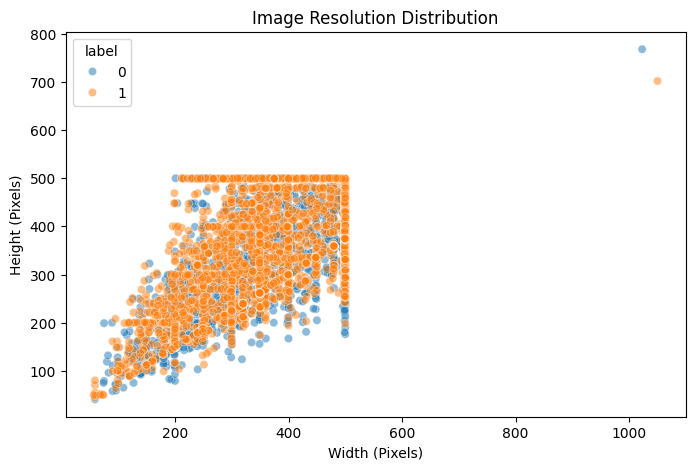

In [9]:
# 1. Sample Image Grid
plt.figure(figsize=(10, 10))
sample_files = (
    df_clean.sample(frac=1, random_state=42)
    .groupby("label")
    .head(4)
    .reset_index(drop=True)
)
for i, row in sample_files.iterrows():
    ax = plt.subplot(4, 2, i + 1)
    img = cv2.cvtColor(cv2.imread(row["filepath"]), cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title("Dog" if row["label"] == 1 else "Cat")
    plt.axis("off")
plt.suptitle("Sample Images from Dataset", fontsize=16)
plt.tight_layout()
plt.show()

# 2. Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df_clean)
plt.title("Class Distribution (0 = Cats, 1 = Dogs)")
plt.show()
# Insight: Checks if the dataset is balanced.

# 3. Image Dimensions Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x="width", y="height", hue="label", data=df_clean, alpha=0.5)
plt.title("Image Resolution Distribution")
plt.xlabel("Width (Pixels)")
plt.ylabel("Height (Pixels)")
plt.show()
# Insight: Shows the massive variance in image sizes, justifying the need to resize all images to a uniform target for the CNN.

### Conclusion

- The sample images are good quality images
- Both classes are equally distributed
- Resolution seems to cap out at `500 x 500`, with the lowest being somewhere around `20 x 20`.

## Feature Selection

### Mutual Information Classification

In [10]:
# 1. Separate features and target from the cleaned dataset
X_fs = df_clean.drop(columns=["filename", "filepath", "label", "width", "height"])
y_fs = df_clean["label"]

# 2. Calculate Mutual Information scores
mi_scores = mutual_info_classif(X_fs, y_fs, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X_fs.columns).sort_values(ascending=False)

print("--- Mutual Information Scores (Excluding Dimensions) ---")
print(mi_scores_series)

# 3. Select features with a score greater than a slightly lowered baseline threshold (e.g., 0.005)
selected_features = mi_scores_series[mi_scores_series > 0.005].index.tolist()

print(f"\nFeatures selected for modeling: {selected_features}")

# 4. Create the finalized tabular feature set
X_tab_final = df_clean[selected_features]
y_tab_final = df_clean["label"]

--- Mutual Information Scores (Excluding Dimensions) ---
edge_intensity    0.013946
brightness        0.007640
contrast          0.000000
rb_diff           0.000000
dtype: float64

Features selected for modeling: ['edge_intensity', 'brightness']


## Machine Learning

### Input - Target Feature Split

In [11]:
X_tab = df_clean[selected_features]
y_tab = df_clean["label"]

print(f"Final features selected: {X_tab.columns.tolist()}")
print(f"Final shape of X: {X_tab.shape}")
print(f"Final shape of y: {y_tab.shape}")

Final features selected: ['edge_intensity', 'brightness']
Final shape of X: (7952, 2)
Final shape of y: (7952,)


### Train - Test Split

In [12]:
X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(
    X_tab, y_tab, test_size=0.2, random_state=42, stratify=y_tab
)

print(f"X_train_tab shape: {X_train_tab.shape}")
print(f"X_test_tab shape: {X_test_tab.shape}")
print(f"y_train_tab shape: {y_train_tab.shape}")
print(f"y_test_tab shape: {y_test_tab.shape}")

X_train_tab shape: (6361, 2)
X_test_tab shape: (1591, 2)
y_train_tab shape: (6361,)
y_test_tab shape: (1591,)


### Defining Preprocessors

In [13]:
num_cols = X_tab.columns.tolist()

# ---------------------------------------------------------
# PIPELINE 1: For Linear/Distance Models (Logistic Regression)
# Strategy: StandardScaler
# ---------------------------------------------------------
linear_preprocessor = ColumnTransformer([("num", StandardScaler(), num_cols)])

# ---------------------------------------------------------
# PIPELINE 2: For Tree-Based Models (RF, XGB, LightGBM, DT)
# Strategy: Passthrough (Trees are scale-invariant)
# ---------------------------------------------------------
tree_preprocessor = ColumnTransformer([("num", "passthrough", num_cols)])

### Defining Models

In [14]:
ml_models = {
    "Logistic Regression": Pipeline(
        [("pre", linear_preprocessor), ("clf", LogisticRegression(random_state=42))]
    ),
    "Decision Tree": Pipeline(
        [("pre", tree_preprocessor), ("clf", DecisionTreeClassifier(random_state=42))]
    ),
    "Random Forest": Pipeline(
        [("pre", tree_preprocessor), ("clf", RandomForestClassifier(random_state=42))]
    ),
    "XGBoost": Pipeline(
        [
            ("pre", tree_preprocessor),
            (
                "clf",
                XGBClassifier(device="cuda", eval_metric="logloss", random_state=42),
            ),
        ]
    ),
    "LightGBM": Pipeline(
        [
            ("pre", tree_preprocessor),
            ("clf", LGBMClassifier(device="gpu", verbose=-1, random_state=42)),
        ]
    ),
}

### Training Models

In [15]:
results = []
for name, model in ml_models.items():
    model.fit(X_train_tab, y_train_tab)
    preds = model.predict(X_test_tab)

    # Using Accuracy as the primary metric for this comparison
    acc = accuracy_score(y_test_tab, preds)
    results.append({"Model": name, "Accuracy": acc})
    print(f"Training done for {name}")

ML_Results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
display(ML_Results)

Training done for Logistic Regression
Training done for Decision Tree
Training done for Random Forest
Training done for XGBoost
Training done for LightGBM


,Model,Accuracy
0,Logistic Regression,0.571967
4,LightGBM,0.544312
2,Random Forest,0.525456
3,XGBoost,0.524199
1,Decision Tree,0.520427


Logistic Regression is the most basic ML model here and since it is able to outperform all the other models, next step is to use hyperparameter tuning on Logistic Regression.

### Hyperparameter Tuning

In [16]:
param_grid_lr = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear"],
}

grid_search_lr = GridSearchCV(
    ml_models["Logistic Regression"], param_grid_lr, cv=5, scoring="accuracy", verbose=1
)

print("Starting Hyperparameter Tuning for Logistic Regression...")
grid_search_lr.fit(X_train_tab, y_train_tab)

# Extract best model
best_lr_model = grid_search_lr.best_estimator_
best_lr_model

Starting Hyperparameter Tuning for Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,th

In [17]:
print(f"\nBest Parameters: {grid_search_lr.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search_lr.best_score_:.4f}")


Best Parameters: {'clf__C': 1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.5700


In [18]:
# Evaluate on Test Set
final_lr_preds = best_lr_model.predict(X_test_tab)

final_lr_acc = accuracy_score(y_test_tab, final_lr_preds)
final_lr_prec = precision_score(y_test_tab, final_lr_preds)
final_lr_rec = recall_score(y_test_tab, final_lr_preds)
final_lr_f1 = f1_score(y_test_tab, final_lr_preds)
final_lr_auc = roc_auc_score(y_test_tab, best_lr_model.predict_proba(X_test_tab)[:, 1])
final_lr_classification_report = classification_report(y_test_tab, final_lr_preds)

print("\n--- Final Logistic Regression Performance on Test Set ---")
print(f"Accuracy: {final_lr_acc:.4f}")
print(f"Precision: {final_lr_prec:.4f}")
print(f"Recall: {final_lr_rec:.4f}")
print(f"F1-Score: {final_lr_f1:.4f}")
print(f"AUC-ROC: {final_lr_auc:.4f}")

print("\n--- Classification Report ---")
print(final_lr_classification_report)


--- Final Logistic Regression Performance on Test Set ---
Accuracy: 0.5720
Precision: 0.5738
Recall: 0.5702
F1-Score: 0.5720
AUC-ROC: 0.6037

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.57      0.57      0.57       793
           1       0.57      0.57      0.57       798

    accuracy                           0.57      1591
   macro avg       0.57      0.57      0.57      1591
weighted avg       0.57      0.57      0.57      1591



## Deep Learning - CNN

In [19]:
# ---------------------------------------------------------
# 1. SETUP: Data Loading for CNN (Subsampled for Speed)
# ---------------------------------------------------------
cnn_img_size = (128, 128)

# Extract 20% sample paths and labels from our cleaned dataframe
search_df = df_clean.sample(frac=0.2, random_state=42).reset_index(drop=True)
X_paths = search_df["filepath"].values
y_search = search_df["label"].values

print(f"Loading {len(X_paths)} images into memory for Hyperparameter Search...")

X_search_list = []
for path in X_paths:
    img = cv2.imread(path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, cnn_img_size)
        X_search_list.append(img)
    else:
        # In case an image fails to load, we must maintain alignment with y_search
        X_search_list.append(np.zeros((128, 128, 3)))

X_search = np.array(X_search_list)


# ---------------------------------------------------------
# 2. HELPER: Model Builder (6 Hidden Layers)
# ---------------------------------------------------------
def build_cnn(optimizer_name, lr):
    keras.backend.clear_session()

    model = Sequential(
        [
            keras.Input(shape=(128, 128, 3)),
            Rescaling(1.0 / 255),
            # Hidden Layer 1: Conv2D
            Conv2D(32, (3, 3), activation="relu", padding="same"),
            MaxPooling2D(2, 2),
            # Hidden Layer 2: Conv2D
            Conv2D(64, (3, 3), activation="relu", padding="same"),
            MaxPooling2D(2, 2),
            # Hidden Layer 3: Conv2D
            Conv2D(128, (3, 3), activation="relu", padding="same"),
            MaxPooling2D(2, 2),
            Flatten(),
            # Hidden Layer 4: Dense
            Dense(256, activation="relu"),
            Dropout(0.5),
            # Hidden Layer 5: Dense
            Dense(128, activation="relu"),
            Dropout(0.3),
            # Hidden Layer 6: Dense
            Dense(64, activation="relu"),
            # Output Layer
            Dense(1, activation="sigmoid"),
        ]
    )

    if optimizer_name == "Adam":
        opt = optimizers.Adam(learning_rate=lr)
    else:
        opt = optimizers.RMSprop(learning_rate=lr)

    model.compile(loss="binary_crossentropy", optimizer=opt, metrics=["accuracy"])
    return model

Loading 1590 images into memory for Hyperparameter Search...


### Finding the Best Configuration

In [20]:
# ---------------------------------------------------------
# 3. EXECUTE: The CV Loop
# ---------------------------------------------------------
optimizers_list = ["Adam", "RMSprop"]
learning_rates = [0.001, 0.0001]
batch_sizes = [32, 64]

kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_results_list = []

print("\nStarting FAST 3-Fold CV Search...")
print("-" * 65)

for opt_name in optimizers_list:
    for lr in learning_rates:
        for batch in batch_sizes:
            fold_accs = []
            config_name = f"{opt_name}_LR{lr}_BS{batch}"
            print(f"Testing: {config_name}...", end=" ", flush=True)

            start_time = time.perf_counter()

            for train_idx, val_idx in kfold.split(X_search, y_search):
                X_fold_train, X_fold_val = X_search[train_idx], X_search[val_idx]
                y_fold_train, y_fold_val = y_search[train_idx], y_search[val_idx]

                # Handling class weights to ensure balanced learning
                cw = class_weight.compute_class_weight(
                    "balanced", classes=np.unique(y_fold_train), y=y_fold_train
                )
                cw_dict = {0: cw[0], 1: cw[1]}

                model = build_cnn(opt_name, lr)
                es = EarlyStopping(
                    monitor="val_loss", patience=5, restore_best_weights=True
                )

                model.fit(
                    X_fold_train,
                    y_fold_train,
                    epochs=20,
                    batch_size=batch,
                    validation_data=(X_fold_val, y_fold_val),
                    callbacks=[es],
                    class_weight=cw_dict,
                    verbose=0,
                )

                y_pred = (model.predict(X_fold_val, verbose=0) > 0.5).astype(int)
                fold_accs.append(accuracy_score(y_fold_val, y_pred))

            mean_acc = np.mean(fold_accs)
            std_acc = np.std(fold_accs)
            
            elapsed = time.perf_counter() - start_time
            print(f"DONE (Acc: {mean_acc:.4f} ± {std_acc:.4f} | Time: {elapsed:.1f}s)")

            cv_results_list.append(
                {
                    "Optimizer": opt_name,
                    "LR": lr,
                    "BS": batch,
                    "Mean Accuracy": mean_acc,
                    "Std Accuracy": std_acc,
                    "Time (s)": elapsed,
                }
            )

# ---------------------------------------------------------
# 4. RESULTS
# ---------------------------------------------------------
CV_Results_CNN = pd.DataFrame(cv_results_list).sort_values(
    by="Mean Accuracy", ascending=False
)
print("\n" + "=" * 40)
print("TOP CONFIGURATIONS (CNN SEARCH)")
print("=" * 40)
print(CV_Results_CNN.head(5))


Starting FAST 3-Fold CV Search...
-----------------------------------------------------------------
Testing: Adam_LR0.001_BS32... DONE (Acc: 0.6327 ± 0.0100 | Time: 21.8s)
Testing: Adam_LR0.001_BS64... DONE (Acc: 0.6585 ± 0.0282 | Time: 20.5s)
Testing: Adam_LR0.0001_BS32... DONE (Acc: 0.7038 ± 0.0285 | Time: 31.5s)
Testing: Adam_LR0.0001_BS64... DONE (Acc: 0.6818 ± 0.0229 | Time: 27.4s)
Testing: RMSprop_LR0.001_BS32... DONE (Acc: 0.6654 ± 0.0401 | Time: 25.5s)
Testing: RMSprop_LR0.001_BS64... DONE (Acc: 0.6931 ± 0.0231 | Time: 26.1s)
Testing: RMSprop_LR0.0001_BS32... DONE (Acc: 0.6673 ± 0.0539 | Time: 29.4s)
Testing: RMSprop_LR0.0001_BS64... DONE (Acc: 0.6277 ± 0.0118 | Time: 26.6s)

TOP CONFIGURATIONS (CNN SEARCH)
  Optimizer      LR  BS  Mean Accuracy  Std Accuracy   Time (s)
2      Adam  0.0001  32       0.703774      0.028532  31.453836
5   RMSprop  0.0010  64       0.693082      0.023074  26.087727
3      Adam  0.0001  64       0.681761      0.022867  27.401864
6   RMSprop  0.000

In [21]:
CV_Results_CNN.to_csv("../data/cat_and_dog/cnn_cv_results.csv", index=False)

In [22]:
CV_Results_CNN = pd.read_csv("../data/cat_and_dog/cnn_cv_results.csv")
CV_Results_CNN.head()

,Optimizer,LR,BS,Mean Accuracy,Std Accuracy,Time (s)
0,Adam,0.0001,32,0.703774,0.028532,31.453836
1,RMSprop,0.0010,64,0.693082,0.023074,26.087727
2,Adam,0.0001,64,0.681761,0.022867,27.401864
3,RMSprop,0.0001,32,0.667296,0.053861,29.444391
4,RMSprop,0.0010,32,0.665409,0.040094,25.514077


#### Conclusion

Best CNN Cofiguration is

- **Optimizer:** Adam
- **Learning Rate:** 0.0001
- **Batch Size:** 64

Next step is to build the best configuration model and evaluate it

### Training the Best Configuration

In [23]:
# 1. Extract best hyperparameters dynamically
best_config = CV_Results_CNN.iloc[0]
best_opt_name = best_config["Optimizer"]
best_lr = best_config["LR"]
best_bs = int(best_config["BS"])

print(f"Final Model Configuration:")
print(f"- Optimizer: {best_opt_name}")
print(f"- Learning Rate: {best_lr}")
print(f"- Batch Size: {best_bs}")

# 2. Load the full dataset with Channels-Last permutation AND un-scaling
transform = transforms.Compose(
    [
        transforms.Resize(cnn_img_size),
        transforms.ToTensor(),  # Scales to [0, 1], shape (C, H, W)
        transforms.Lambda(
            lambda x: x * 255.0
        ),  # Multiply by 255 so Keras Rescaling works correctly
        transforms.Lambda(
            lambda x: x.permute(1, 2, 0)
        ),  # Permute to Keras expected (H, W, C)
    ]
)

full_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(
    full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

train_ds = DataLoader(train_subset, batch_size=best_bs, shuffle=True)
val_ds = DataLoader(val_subset, batch_size=best_bs, shuffle=False)

# 3. Build and train the final model
final_cnn_model = build_cnn(best_opt_name, best_lr)

es = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-6)

history = final_cnn_model.fit(
    train_ds, validation_data=val_ds, epochs=50, callbacks=[es, rlr]
)

Final Model Configuration:
- Optimizer: Adam
- Learning Rate: 0.0001
- Batch Size: 32
Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.5394 - loss: 0.6875 - val_accuracy: 0.5203 - val_loss: 0.6763 - learning_rate: 1.0000e-04
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.6254 - loss: 0.6480 - val_accuracy: 0.6284 - val_loss: 0.6319 - learning_rate: 1.0000e-04
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.6889 - loss: 0.5918 - val_accuracy: 0.7146 - val_loss: 0.5763 - learning_rate: 1.0000e-04
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - accuracy: 0.7152 - loss: 0.5669 - val_accuracy: 0.7196 - val_loss: 0.5338 - learning_rate: 1.0000e-04
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - accuracy: 0.7392 - loss: 0.5302 - val_accuracy: 0.7420 - val_loss: 0.5050 - learning_rate: 1.0000e-04
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - accuracy: 0.7625 - loss: 0.5013 - val_accuracy: 0.7558 - val_loss: 0

In [24]:
final_cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,569,989 (97.54 MB)

 Trainable params: 8,523,329 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,046,660 (65.03 MB)

### Evaluating the Best Configuration

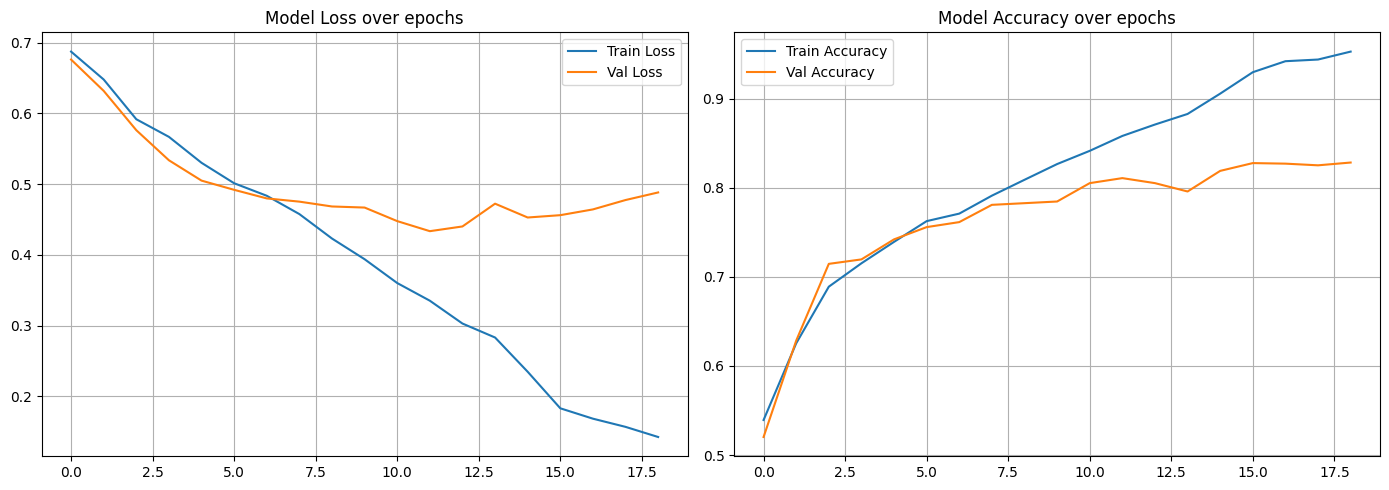

In [25]:
# 4. Visualize Training Progress
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss over epochs")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy over epochs")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
# 1. Prepare Test Data using the same Torch-native pipeline
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=best_bs, shuffle=False)

# 2. Get Predictions
y_true = []
for _, labels in test_loader:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

y_pred_probs = final_cnn_model.predict(test_loader)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 3. Calculate CNN Metrics
cnn_acc = accuracy_score(y_true, y_pred)
cnn_prec = precision_score(y_true, y_pred)
cnn_rec = recall_score(y_true, y_pred)
cnn_f1 = f1_score(y_true, y_pred)
cnn_auc = roc_auc_score(y_true, y_pred_probs)

cnn_classification_report = classification_report(y_true, y_pred, target_names=["Cat", "Dog"])

print("\n--- Final CNN Performance on Test Set ---")
print(f"Accuracy: {cnn_acc:.4f}")
print(f"Precision: {cnn_prec:.4f}")
print(f"Recall: {cnn_rec:.4f}")
print(f"F1-Score: {cnn_f1:.4f}")
print(f"AUC-ROC: {cnn_auc:.4f}")

print("\n--- Classification Report ---")
print(cnn_classification_report)

64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step

--- Final CNN Performance on Test Set ---
Accuracy: 0.7914
Precision: 0.8285
Recall: 0.7352
F1-Score: 0.7791
AUC-ROC: 0.8712

--- Classification Report ---
              precision    recall  f1-score   support

         Cat       0.76      0.85      0.80      1011
         Dog       0.83      0.74      0.78      1012

    accuracy                           0.79      2023
   macro avg       0.80      0.79      0.79      2023
weighted avg       0.80      0.79      0.79      2023



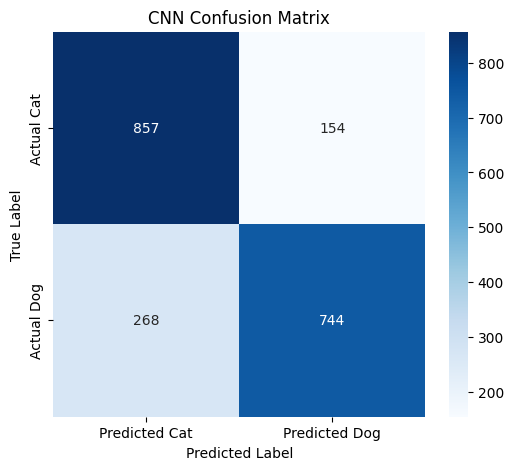

In [27]:
cnn_conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cnn_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Cat", "Predicted Dog"],
    yticklabels=["Actual Cat", "Actual Dog"],
)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Final Model Comparisons

In [28]:
# Final Comparison Table
comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Tuned Logistic Regression": [final_lr_acc, final_lr_prec, final_lr_rec, final_lr_f1, final_lr_auc],
    "Final CNN": [cnn_acc, cnn_prec, cnn_rec, cnn_f1, cnn_auc],
}

comparison_df = pd.DataFrame(comparison_data)
print("\n--- FINAL MODEL COMPARISON ---")
comparison_df


--- FINAL MODEL COMPARISON ---


,Metric,Tuned Logistic Regression,Final CNN
0,Accuracy,0.571967,0.791399
1,Precision,0.573770,0.828508
2,Recall,0.570175,0.735178
3,F1 Score,0.571967,0.779058
4,ROC-AUC,0.603666,0.871239


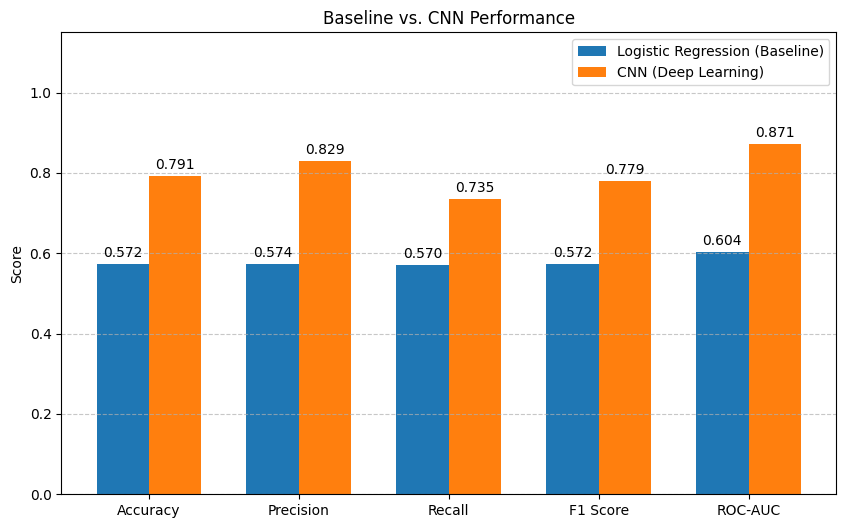

In [29]:
# Visualization of Comparison
plt.figure(figsize=(10, 6))
x = np.arange(len(comparison_df["Metric"]))
width = 0.35

bars1 = plt.bar(
    x - width / 2,
    comparison_df["Tuned Logistic Regression"],
    width,
    label="Logistic Regression (Baseline)",
)
bars2 = plt.bar(
    x + width / 2, comparison_df["Final CNN"], width, label="CNN (Deep Learning)"
)

plt.bar_label(bars1, fmt="%.3f", padding=3)
plt.bar_label(bars2, fmt="%.3f", padding=3)

plt.ylabel("Score")
plt.title("Baseline vs. CNN Performance")
plt.xticks(x, comparison_df["Metric"])
plt.legend()
plt.ylim(0, 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

## Conclusion

CNN is significantly outperforming Tuned Logistic Regression as well, so it is the best model and should be saved in case of using it in future for inference.

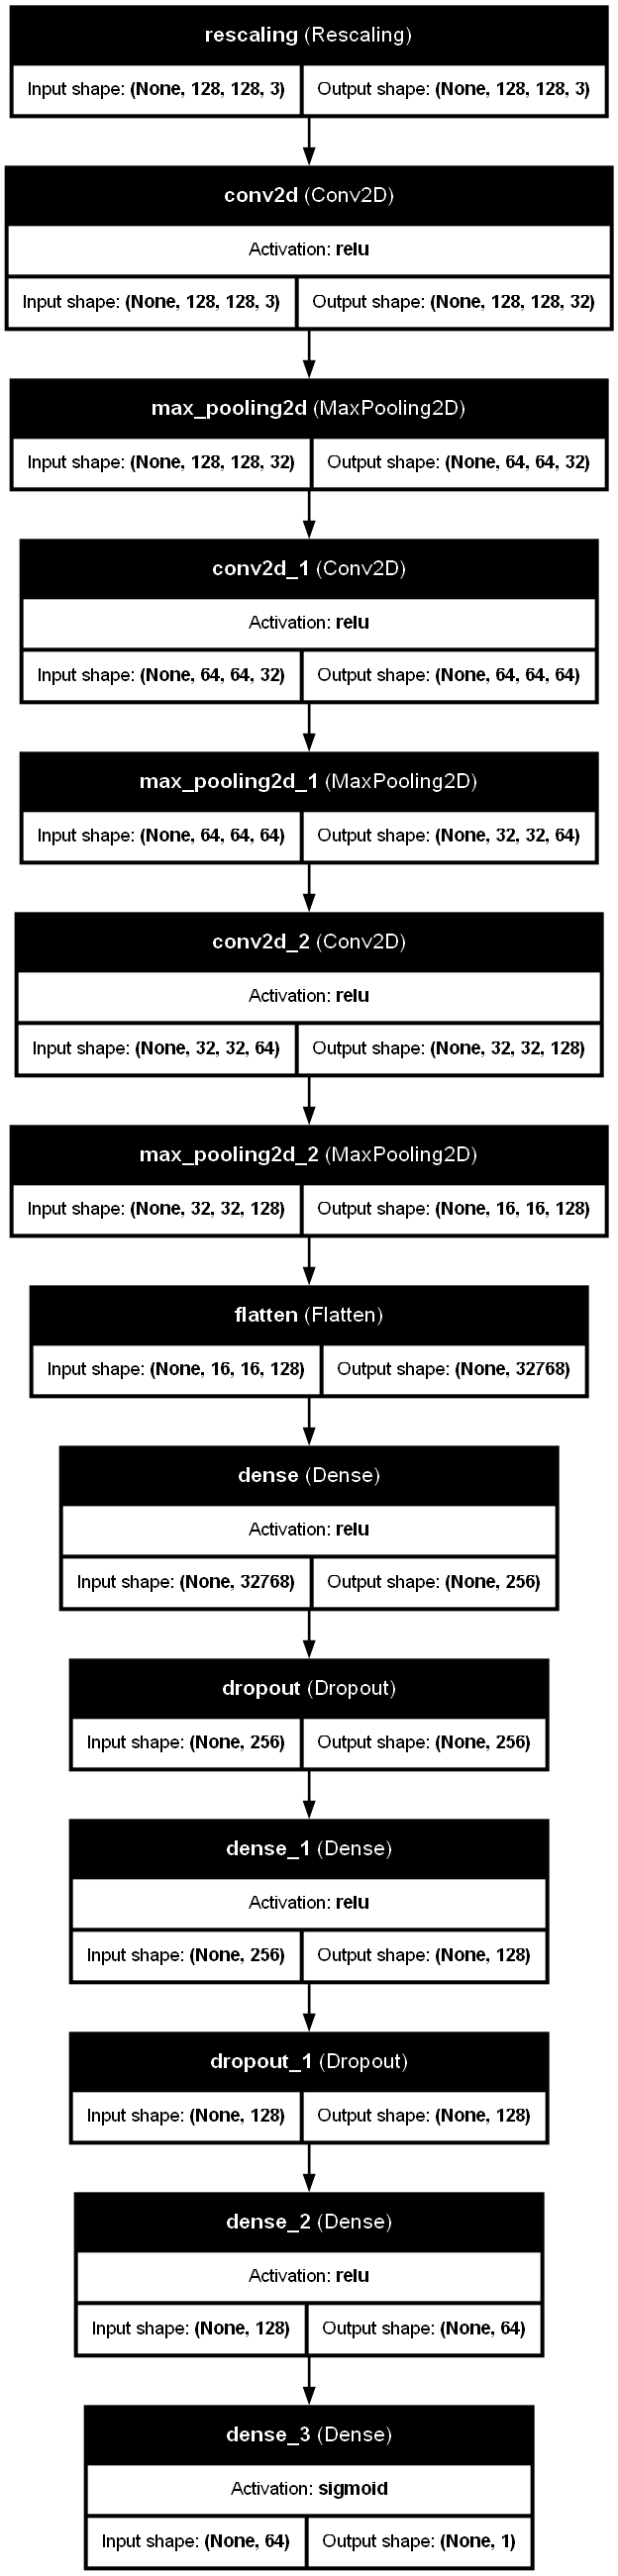

In [30]:
plot_model(
    final_cnn_model,
    to_file="cnn_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
    dpi=96,
)

In [31]:
model_filename = "cat_and_dog_cnn_model.keras"

In [32]:
final_cnn_model.save(model_filename)
print(f"Success! Model and preprocessor saved as: {model_filename}")

Success! Model and preprocessor saved as: cat_and_dog_cnn_model.keras


In [33]:
final_cnn_model = keras.models.load_model(model_filename)
print("Model loaded successfully. Ready for inference or further evaluation.")

Model loaded successfully. Ready for inference or further evaluation.
